# Markov Chain Types — Notes

This notebook builds up every major "type" of Markov chain with a
small runnable example each: DTMC, CTMC, irreducibility, periodicity,
transient/recurrent states, absorbing chains, ergodicity/stationary
distribution, reversibility, higher-order chains, HMMs, MCMC, and MDPs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

## 1. Basics

A Markov chain = states + a transition matrix $P$ where
$P_{ij} = P(X_{t+1}=j \mid X_t=i)$. The Markov property says the next
state depends only on the current state, not the full history.
Every row of $P$ must sum to 1.

In [2]:
states = ["A", "B", "C"]
n = len(states)
idx = {s: i for i, s in enumerate(states)}

P = np.array([
    [0.5, 0.3, 0.2],
    [0.2, 0.5, 0.3],
    [0.1, 0.4, 0.5],
])

assert np.allclose(P.sum(axis=1), 1.0)
pd.DataFrame(P, index=states, columns=states)

,A,B,C
A,0.5,0.3,0.2
B,0.2,0.5,0.3
C,0.1,0.4,0.5


## 2. Discrete-Time Markov Chain (DTMC)

Transitions happen at fixed steps: 1, 2, 3, .... This is the default
"type" — everything else is a variation or extension of this.

In [3]:
def simulate_dtmc(P, states, start, steps, seed=None):
    rng = np.random.default_rng(seed)
    i = idx[start]
    path = [states[i]]
    for _ in range(steps):
        i = rng.choice(n, p=P[i])
        path.append(states[i])
    return path

print("DTMC walk:", " -> ".join(simulate_dtmc(P, states, "A", 10, seed=1)))

DTMC walk: A -> B -> C -> B -> C -> B -> B -> C -> B -> B -> A


## 3. Continuous-Time Markov Chain (CTMC)

Transitions happen at random moments, not fixed steps. Described by a
**rate matrix** $Q$: off-diagonal entries are jump rates, diagonal is
the negative sum of its row. Time until the next jump is exponentially
distributed.

In [4]:
Q = np.array([
    [-0.5,  0.3,  0.2],
    [ 0.4, -0.9,  0.5],
    [ 0.1,  0.6, -0.7],
])

def simulate_ctmc(Q, start_idx, t_max, seed=None):
    rng = np.random.default_rng(seed)
    t, i = 0.0, start_idx
    trace = [(t, i)]
    while t < t_max:
        rate_out = -Q[i, i]
        t += rng.exponential(1 / rate_out)
        probs = Q[i].copy(); probs[i] = 0; probs /= probs.sum()
        i = rng.choice(len(Q), p=probs)
        trace.append((t, i))
    return trace

trace = simulate_ctmc(Q, start_idx=0, t_max=10, seed=2)
for t, i in trace:
    print(f"t={t:5.2f}  state={states[i]}")

t= 0.00  state=A
t= 0.26  state=B
t= 0.83  state=A
t= 3.26  state=C
t= 3.61  state=A
t= 4.62  state=C
t= 7.26  state=B
t= 8.29  state=C
t= 8.92  state=B
t=10.76  state=C


## 4. Irreducible vs Reducible

**Irreducible**: every state can eventually reach every other state
(one connected component). **Reducible**: the chain splits into
groups that can't all reach each other.

In [5]:
def build_graph(P, states):
    G = nx.DiGraph()
    G.add_nodes_from(states)
    for i, s1 in enumerate(states):
        for j, s2 in enumerate(states):
            if P[i, j] > 0:
                G.add_edge(s1, s2)
    return G

G = build_graph(P, states)
print("Irreducible?", nx.is_strongly_connected(G))

# A reducible example: C can never get back to A or B
P_reducible = np.array([
    [0.5, 0.5, 0.0],
    [0.3, 0.7, 0.0],
    [0.2, 0.3, 0.5],
])
G2 = build_graph(P_reducible, states)
print("Reducible example irreducible?", nx.is_strongly_connected(G2))

Irreducible? True
Reducible example irreducible? False


## 5. Periodic vs Aperiodic

A state's **period** is the GCD of all cycle lengths returning to it.
Period 1 = **aperiodic**. A strict A→B→C→A loop has period 3
(**periodic**) — you can only return every 3 steps.

In [6]:
def state_period(G, state):
    cycle_lengths = []
    for cycle in nx.simple_cycles(G):
        if state in cycle:
            cycle_lengths.append(len(cycle))
    if not cycle_lengths:
        return None
    return np.gcd.reduce(cycle_lengths)

# Periodic example: strict 3-cycle
G_periodic = nx.DiGraph()
G_periodic.add_edges_from([("A","B"), ("B","C"), ("C","A")])
print("Period of A in strict cycle:", state_period(G_periodic, "A"))

# Aperiodic example: our main chain (has a self-loop / multiple return lengths)
print("Period of A in main chain:", state_period(G, "A"))

Period of A in strict cycle: 3
Period of A in main chain: 1


## 6. Transient vs Recurrent

**Transient**: once you leave, there's a chance you never return.
**Recurrent**: you're guaranteed to return eventually. We can check
this empirically by simulating many long runs and seeing whether a
state keeps getting revisited.

In [7]:
def is_recurrent_empirical(P, states, state, n_trials=200, steps=500):
    i0 = idx[state]
    returns = 0
    for _ in range(n_trials):
        i = i0
        rng = np.random.default_rng()
        for _ in range(steps):
            i = rng.choice(n, p=P[i])
            if i == i0:
                returns += 1
                break
    return returns / n_trials  # close to 1.0 => recurrent

for s in states:
    print(f"{s}: empirical return probability = {is_recurrent_empirical(P, states, s):.2f}")

A: empirical return probability = 1.00
B: empirical return probability = 1.00
C: empirical return probability = 1.00


## 7. Absorbing Markov Chains

At least one state, once entered, can never be left ($P_{ii}=1$). Key
questions: probability of ending in each absorbing state, and expected
steps to absorption (via the fundamental matrix $N=(I-Q)^{-1}$).

In [8]:
states_abs = ["Start", "Mid1", "Mid2", "End"]
idx_abs = {s: i for i, s in enumerate(states_abs)}

P_abs = np.array([
    [0.0, 0.6, 0.4, 0.0],
    [0.0, 0.3, 0.3, 0.4],
    [0.0, 0.2, 0.3, 0.5],
    [0.0, 0.0, 0.0, 1.0],   # End is absorbing
])

transient = ["Start", "Mid1", "Mid2"]
t_idx = [idx_abs[s] for s in transient]

Q_sub = P_abs[np.ix_(t_idx, t_idx)]
I = np.eye(len(t_idx))
N = np.linalg.inv(I - Q_sub)
expected_steps = N.sum(axis=1)

pd.Series(expected_steps, index=transient, name="expected steps to absorption").round(2)

Start    3.23
Mid1     2.33
Mid2     2.09
Name: expected steps to absorption, dtype: float64

## 8. Ergodic (Regular) Chains & Stationary Distribution

A chain is **ergodic** if it's irreducible + aperiodic + positive
recurrent. Ergodic chains converge to a unique stationary distribution
$\pi$ regardless of starting state, where $\pi P = \pi$.

In [10]:
def stationary_distribution(P, iters=5000, tol=1e-12):
    pi = np.ones(len(P)) / len(P)
    for _ in range(iters):
        new_pi = pi @ P
        if np.max(np.abs(new_pi - pi)) < tol:
            break
        pi = new_pi
    return pi / pi.sum()

pi = stationary_distribution(P)
print("Stationary distribution:", dict(zip(states, pi.round(4))))

# Verify: starting from any state, long-run frequency converges to the same pi
for start in states:
    walk = simulate_dtmc(P, states, start, steps=20000, seed=0)
    freqs = pd.Series(walk).value_counts(normalize=True).reindex(states)
    print(f"Empirical freq starting from {start}:", freqs.round(3).to_dict())

Stationary distribution: {'A': np.float64(0.2364), 'B': np.float64(0.4182), 'C': np.float64(0.3455)}
Empirical freq starting from A: {'A': 0.234, 'B': 0.417, 'C': 0.349}
Empirical freq starting from B: {'A': 0.234, 'B': 0.417, 'C': 0.349}
Empirical freq starting from C: {'A': 0.234, 'B': 0.417, 'C': 0.349}


## 9. Reversible Markov Chains

A chain is **reversible** if it satisfies detailed balance:
$\pi_i P_{ij} = \pi_j P_{ji}$ for every pair $i,j$. This means the
chain looks statistically the same run forward or backward in time.

In [12]:
def check_detailed_balance(P, pi, states, tol=1e-6):
    violations = []
    for i in range(len(states)):
        for j in range(len(states)):
            lhs = pi[i] * P[i, j]
            rhs = pi[j] * P[j, i]
            if abs(lhs - rhs) > tol:
                violations.append((states[i], states[j], lhs, rhs))
    return violations

violations = check_detailed_balance(P, pi, states)
print("Reversible?", len(violations) == 0)
if violations:
    print("Violations (state_i, state_j, pi_i*P_ij, pi_j*P_ji):")
    for v in violations[:5]:
        print(v)

Reversible? False
Violations (state_i, state_j, pi_i*P_ij, pi_j*P_ji):
('A', 'B', np.float64(0.07090909090929857), np.float64(0.08363636363631076))
('A', 'C', np.float64(0.047272727272865724), np.float64(0.03454545454541176))
('B', 'A', np.float64(0.08363636363631076), np.float64(0.07090909090929857))
('B', 'C', np.float64(0.12545454545446613), np.float64(0.13818181818164704))
('C', 'A', np.float64(0.03454545454541176), np.float64(0.047272727272865724))


## 10. Higher-Order Markov Chains

In a $k$-th order chain, the next state depends on the last $k$
states, not just the current one. Trick: redefine "state" as a tuple
of recent history, then it's just a regular (1st-order) chain over
the new, bigger state space.

In [13]:
# Toy sequence of observed states
sequence = ["A","B","C","A","B","A","A","B","C","A","B","A","C","A","B"]

def build_order2_counts(sequence):
    counts = {}
    for i in range(len(sequence) - 2):
        key = (sequence[i], sequence[i+1])   # last 2 states = the "state"
        nxt = sequence[i+2]
        counts.setdefault(key, {}).setdefault(nxt, 0)
        counts[key][nxt] += 1
    return counts

counts = build_order2_counts(sequence)
for key, nxt_counts in counts.items():
    total = sum(nxt_counts.values())
    probs = {k: round(v/total, 2) for k, v in nxt_counts.items()}
    print(f"After {key}: next-state probabilities = {probs}")

After ('A', 'B'): next-state probabilities = {'C': 0.5, 'A': 0.5}
After ('B', 'C'): next-state probabilities = {'A': 1.0}
After ('C', 'A'): next-state probabilities = {'B': 1.0}
After ('B', 'A'): next-state probabilities = {'A': 0.5, 'C': 0.5}
After ('A', 'A'): next-state probabilities = {'B': 1.0}
After ('A', 'C'): next-state probabilities = {'A': 1.0}


## 11. Hidden Markov Models (HMM)

The true state is **hidden** — you only observe an emission generated
by that state. Below: hidden states {Rainy, Sunny}, observed emissions
{Walk, Shop, Clean}. We compute the probability of an observation
sequence using the **forward algorithm**.

In [14]:
hidden_states = ["Rainy", "Sunny"]
obs_states = ["Walk", "Shop", "Clean"]

start_prob = np.array([0.6, 0.4])                 # P(hidden state at t=0)
trans_prob = np.array([[0.7, 0.3],                 # hidden -> hidden
                        [0.4, 0.6]])
emit_prob  = np.array([[0.1, 0.4, 0.5],             # hidden -> observation
                        [0.6, 0.3, 0.1]])

observations = ["Walk", "Shop", "Clean"]
obs_idx = [obs_states.index(o) for o in observations]

def forward_algorithm(obs_idx, start_prob, trans_prob, emit_prob):
    n_hidden = len(start_prob)
    T = len(obs_idx)
    alpha = np.zeros((T, n_hidden))
    alpha[0] = start_prob * emit_prob[:, obs_idx[0]]
    for t in range(1, T):
        for j in range(n_hidden):
            alpha[t, j] = np.sum(alpha[t-1] * trans_prob[:, j]) * emit_prob[j, obs_idx[t]]
    return alpha, alpha[-1].sum()

alpha, prob_obs_seq = forward_algorithm(obs_idx, start_prob, trans_prob, emit_prob)
print("P(observations) =", round(prob_obs_seq, 5))
pd.DataFrame(alpha, index=observations, columns=hidden_states)

P(observations) = 0.03361


,Rainy,Sunny
Walk,0.06000,0.240000
Shop,0.05520,0.048600
Clean,0.02904,0.004572


## 12. Markov Chain Monte Carlo (MCMC)

Design a chain whose stationary distribution equals a target
distribution you want to sample from. Below: Metropolis-Hastings
sampling from a target that's hard to sample directly (an unnormalized
bimodal density).

/var/folders/5q/3bzc5mns2p1cmjf0x0b446br0000gn/T/ipykernel_42153/2869189473.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ys /= np.trapz(ys, xs)   # normalize for overlay comparison


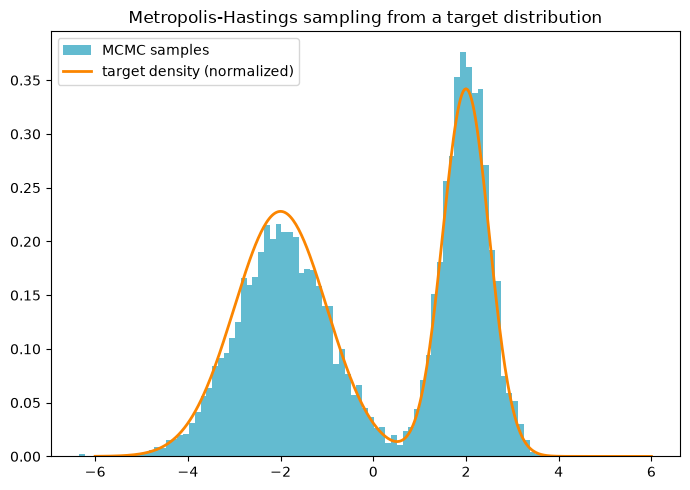

In [16]:
def target_density(x):
    # unnormalized: mixture of two Gaussians
    return 0.6*np.exp(-0.5*((x-2)/0.5)**2) + 0.4*np.exp(-0.5*((x+2)/1.0)**2)

def metropolis_hastings(target, n_samples, start=0.0, step_size=1.0, seed=0):
    rng = np.random.default_rng(seed)
    samples = [start]
    x = start
    for _ in range(n_samples):
        x_proposed = x + rng.normal(0, step_size)
        accept_ratio = target(x_proposed) / target(x)
        if rng.uniform() < accept_ratio:
            x = x_proposed
        samples.append(x)
    return np.array(samples)

samples = metropolis_hastings(target_density, n_samples=20000, seed=3)

plt.hist(samples, bins=80, density=True, color="#219ebc", alpha=0.7, label="MCMC samples")
xs = np.linspace(-6, 6, 400)
ys = target_density(xs)
ys /= np.trapz(ys, xs)   # normalize for overlay comparison
plt.plot(xs, ys, color="#fb8500", lw=2, label="target density (normalized)")
plt.legend()
plt.title("Metropolis-Hastings sampling from a target distribution")
plt.tight_layout()
plt.show()

## 13. Markov Decision Process (MDP)

Adds **actions** and **rewards** to a Markov chain: at each state you
choose an action, get a reward, and move per action-specific
transition probabilities. **Value iteration** finds the best action
per state (the policy) that maximizes long-run reward.

In [17]:
mdp_states = ["Low", "High"]
actions = ["Search", "Wait"]

# transitions[state][action] = {next_state: probability}
transitions = {
    "Low":  {"Search": {"Low": 0.6, "High": 0.4}, "Wait": {"Low": 1.0}},
    "High": {"Search": {"Low": 0.3, "High": 0.7}, "Wait": {"High": 0.8, "Low": 0.2}},
}
# rewards[state][action]
rewards = {
    "Low":  {"Search": -1, "Wait": 0},
    "High": {"Search": 2,  "Wait": 1},
}

gamma = 0.9  # discount factor

def value_iteration(states, actions, transitions, rewards, gamma, iters=100):
    V = {s: 0.0 for s in states}
    for _ in range(iters):
        new_V = {}
        for s in states:
            action_values = []
            for a in actions:
                if a not in transitions[s]:
                    continue
                q = rewards[s][a] + gamma * sum(
                    p * V[s_next] for s_next, p in transitions[s][a].items()
                )
                action_values.append(q)
            new_V[s] = max(action_values)
        V = new_V
    return V

def extract_policy(states, actions, transitions, rewards, V, gamma):
    policy = {}
    for s in states:
        best_a, best_q = None, -np.inf
        for a in actions:
            if a not in transitions[s]:
                continue
            q = rewards[s][a] + gamma * sum(
                p * V[s_next] for s_next, p in transitions[s][a].items()
            )
            if q > best_q:
                best_a, best_q = a, q
        policy[s] = best_a
    return policy

V = value_iteration(mdp_states, actions, transitions, rewards, gamma)
policy = extract_policy(mdp_states, actions, transitions, rewards, V, gamma)

print("State values:", V)
print("Optimal policy:", policy)

State values: {'Low': 4.794347406974678, 'High': 8.903936448070567}
Optimal policy: {'Low': 'Search', 'High': 'Search'}


## Summary

| Type | Key idea |
|---|---|
| DTMC | transitions at fixed discrete steps |
| CTMC | transitions at random times, via a rate matrix |
| Irreducible / Reducible | can every state reach every other |
| Periodic / Aperiodic | forced return-cycle length |
| Transient / Recurrent | do you return to a state eventually |
| Absorbing | some state you can never leave |
| Ergodic | irreducible + aperiodic + positive recurrent -> unique stationary $\pi$ |
| Reversible | satisfies detailed balance |
| Higher-order | next state depends on last $k$ states |
| Hidden Markov Model | true state unobserved, inferred from emissions |
| MCMC | chain engineered to sample from a target distribution |
| MDP | chain + actions + rewards -> optimal policy |

**Next step for your test-automation use case:** the DTMC (step 3),
absorbing chain (step 8), and ergodic/stationary distribution (step 9)
sections are the ones directly reusable in the test-generation
notebook from earlier — the rest (HMM, MCMC, MDP) are good to
recognize by name but less commonly needed unless you move toward
inferring hidden system state or building a smarter, reward-driven
test-path chooser.